In [9]:
import h5py
import os
import numpy as np
import matplotlib.pyplot as plt

mat_pth = "/gpfs/home/cw1722/sponge/JAX-LaB/assets/374_09_03_256.mat"
npy_pth = "/gpfs/home/cw1722/sponge/spongecore/data/structure/poly_sphere/poly_sphere_0000.npy"

def _load_geometry(path: str) -> np.ndarray:
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        arr = np.load(path)
        return arr.astype(bool)
    elif ext == ".mat":
        with h5py.File(path, "r") as f:
            return np.array(f["bin"], dtype=bool)
    else:
        raise ValueError(f"Unsupported geometry format '{ext}'. Use .npy or .mat")

mat = _load_geometry(mat_pth)
npy = _load_geometry(npy_pth)


In [16]:
def porosity(geo):
    pore = geo == 0
    
    pore_count = np.sum(pore)
    total = geo.size
    
    return pore_count / total

0.19618582725524902


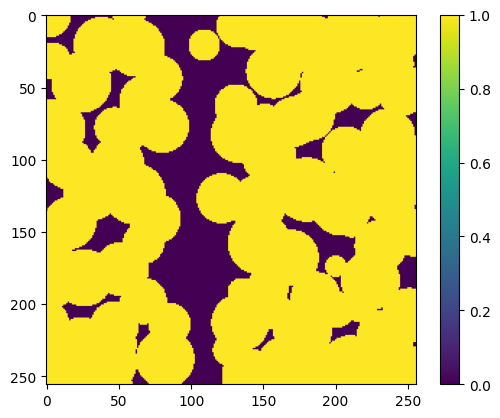

0.25762438774108887


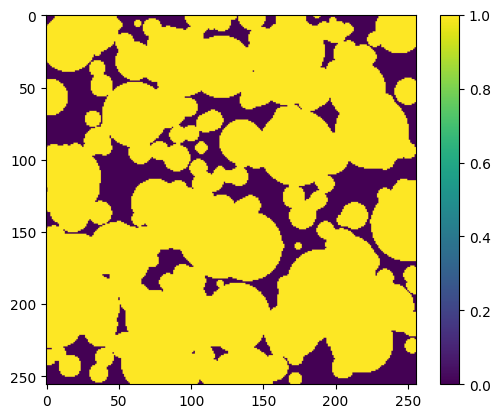

In [17]:
plt.imshow(mat[:, :, 100])
print(porosity(mat))
plt.colorbar()
plt.show()

plt.imshow(npy[:, :, 100])
print(porosity(npy))
plt.colorbar()
plt.show()